# 📊 Комплексный анализ выкупов и показателей доставки
## Artraid - Когортный анализ и метрики качества

In [33]:
# Импорт необходимых библиотек и настройка для Jupyter
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей - минимализм и консистентность с .py файлами
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# Убираем автоматическую палитру seaborn (она дает уродские цвета)
# Используем явные цвета как в .py файлах

# Пути к данным
BASE_DIR = Path('.')
INPUT_PATH = Path(r'../data_preparation/data/clean/clean_data.xlsx')

In [34]:
# Функция для преобразования булевых значений
def to_truthy_mask(series: pd.Series) -> pd.Series:
    """Преобразование разнородных булевых значений в надежную маску"""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce").fillna(0).eq(1)
    
    normalized = series.astype("string").str.strip().str.lower().fillna("false")
    return normalized.isin({"true", "1", "yes", "y", "да"})

In [35]:
# Загрузка данных
df = pd.read_excel(INPUT_PATH)

# Удаляем строки с неизвестным исходом
if "outcome_unknown" in df.columns:
    unknown_mask = to_truthy_mask(df["outcome_unknown"])
    df = df.loc[~unknown_mask].copy()

# Преобразуем buyout_flag в boolean
df["is_buyout"] = to_truthy_mask(df["buyout_flag"])

# Заполняем пустые значения в источниках
df["lead_source_category"] = df["lead_source_category"].fillna("Без источника")

# Конвертируем дату продажи
df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")

## 1️⃣ Анализ выкупов по источникам лидов (lead_Источник)

In [36]:
# Анализ по источникам лидов
stats_source = df.groupby("lead_source_category").agg({
    "is_buyout": ["sum", "count"]
}).round(4)

stats_source.columns = ["buyout_count", "total_count"]
stats_source = stats_source.reset_index()
stats_source["buyout_rate"] = (stats_source["buyout_count"] / stats_source["total_count"]).round(4)
stats_source["buyout_rate_pct"] = (stats_source["buyout_rate"] * 100).round(2)

# Сортируем по количеству выкупов
stats_source = stats_source.sort_values("buyout_count", ascending=False)

# Фильтруем только источники с хотя бы 10 покупками
stats_source_filtered = stats_source[stats_source["buyout_count"] >= 10].copy()

## 2️⃣ Когортный анализ выкупа по месяцам (lead_Источник × Sale Month)

In [37]:
# Создаем месячный период
df_cohort = df.copy()
df_cohort["sale_month"] = df_cohort["sale_date"].dt.to_period("M").astype(str)

# Когортная таблица: источник × месяц покупки
cohort = (
    df_cohort.groupby(["lead_source_category", "sale_month"])
    .agg(
        buyout_count=("is_buyout", "sum"),
        total_count=("is_buyout", "count")
    )
    .reset_index()
)

cohort["buyout_rate_pct"] = (
    cohort["buyout_count"] / cohort["total_count"] * 100
).round(2)

pivot = cohort.pivot(
    index="lead_source_category",
    columns="sale_month",
    values="buyout_rate_pct"
)

pivot_sorted = pivot.sort_index(axis=1)

# Сортируем строки (источники) по общему количеству заказов - большие вверху
total_orders_by_source = cohort.groupby("lead_source_category")["total_count"].sum().sort_values(ascending=False)
pivot_sorted = pivot_sorted.loc[total_orders_by_source.index]

## 3️⃣ Анализ временных показателей доставки по неделям

In [38]:
# Подготовка данных для анализа по неделям
df_timing = df.dropna(subset=["sale_date", "sale_ts", "handed_to_delivery_ts", "days_to_outcome"]).copy()

# Конвертируем временные метки в datetime
df_timing["sale_ts"] = pd.to_datetime(df_timing["sale_ts"], errors="coerce")
df_timing["handed_to_delivery_ts"] = pd.to_datetime(df_timing["handed_to_delivery_ts"], errors="coerce")

# Вычисляем дни от продажи до доставки/выдачи
df_timing["days_sale_to_delivery"] = (df_timing["handed_to_delivery_ts"] - df_timing["sale_ts"]).dt.total_seconds() / (24 * 3600)

# Создаем неделю
df_timing["year_week"] = df_timing["sale_date"].dt.strftime("%G-W%V")
df_timing["week_start"] = df_timing["sale_date"].dt.to_period("W").apply(lambda x: x.start_time)

# Рассчитываем статистику по неделям
cohort_timing = df_timing.groupby("year_week").agg({
    "days_sale_to_delivery": ["mean", "std", "count"],
    "days_to_outcome": ["mean", "std"],
    "week_start": "first"
}).round(2)

cohort_timing.columns = [
    "sale_to_delivery_mean", "sale_to_delivery_std", "count",
    "to_outcome_mean", "to_outcome_std",
    "week_start"
]

cohort_timing = cohort_timing.sort_values("week_start").reset_index()

## 📊 Визуализация результатов анализа

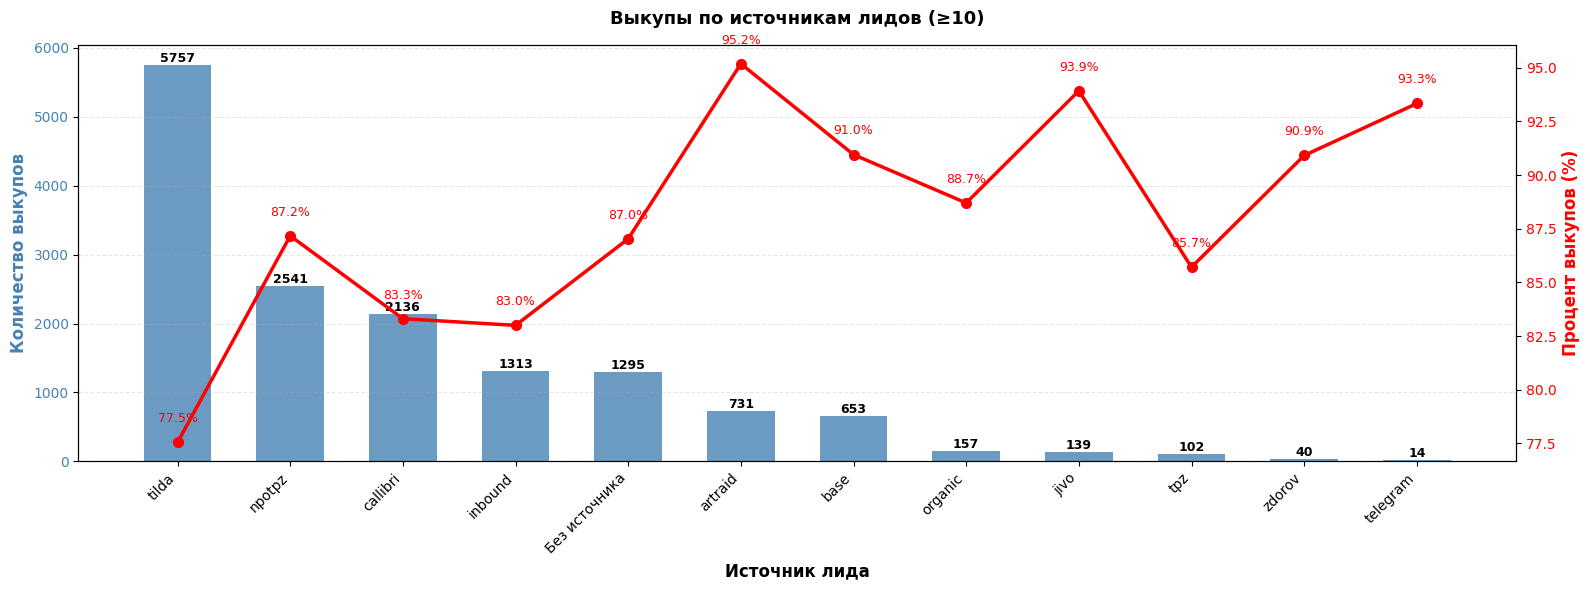

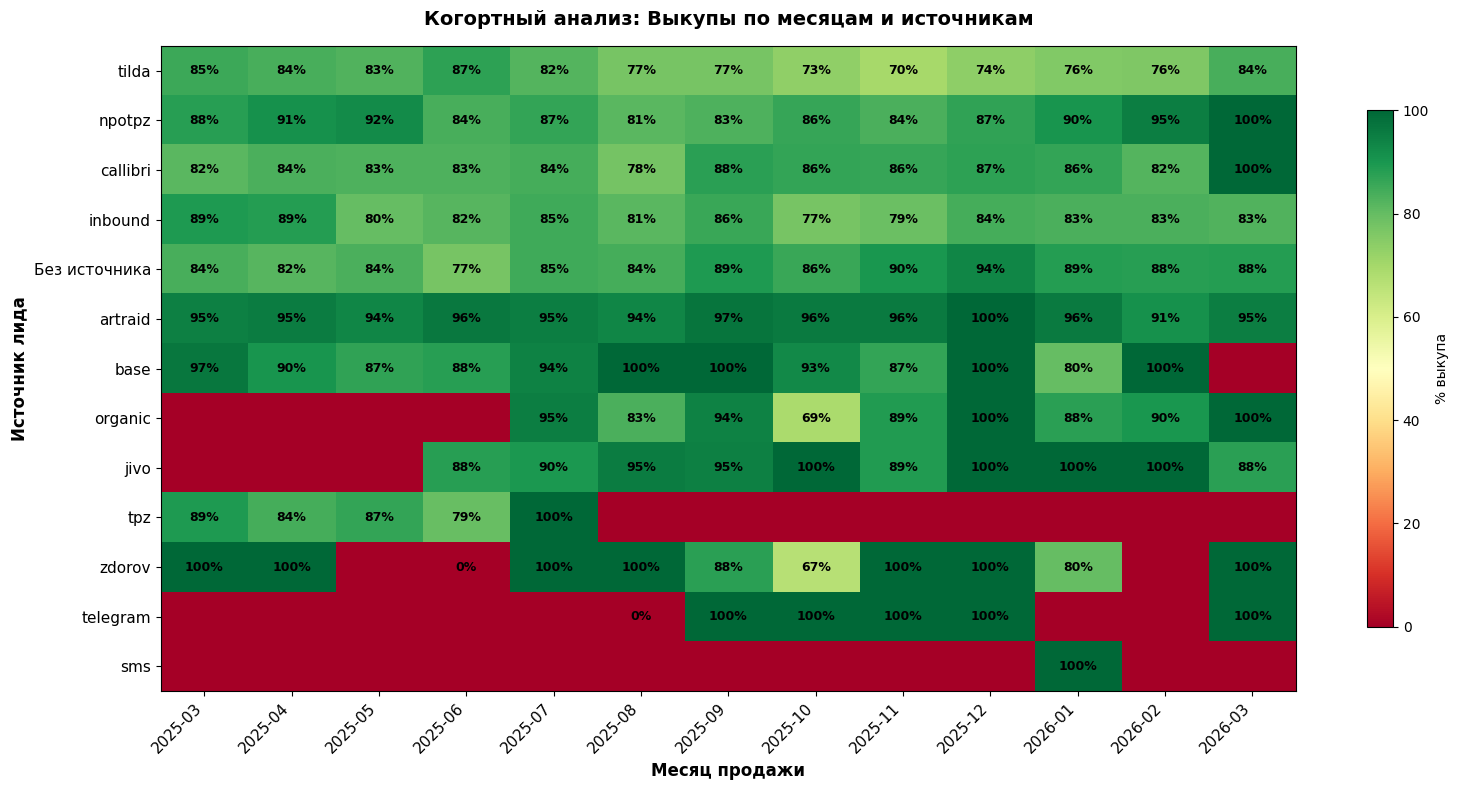

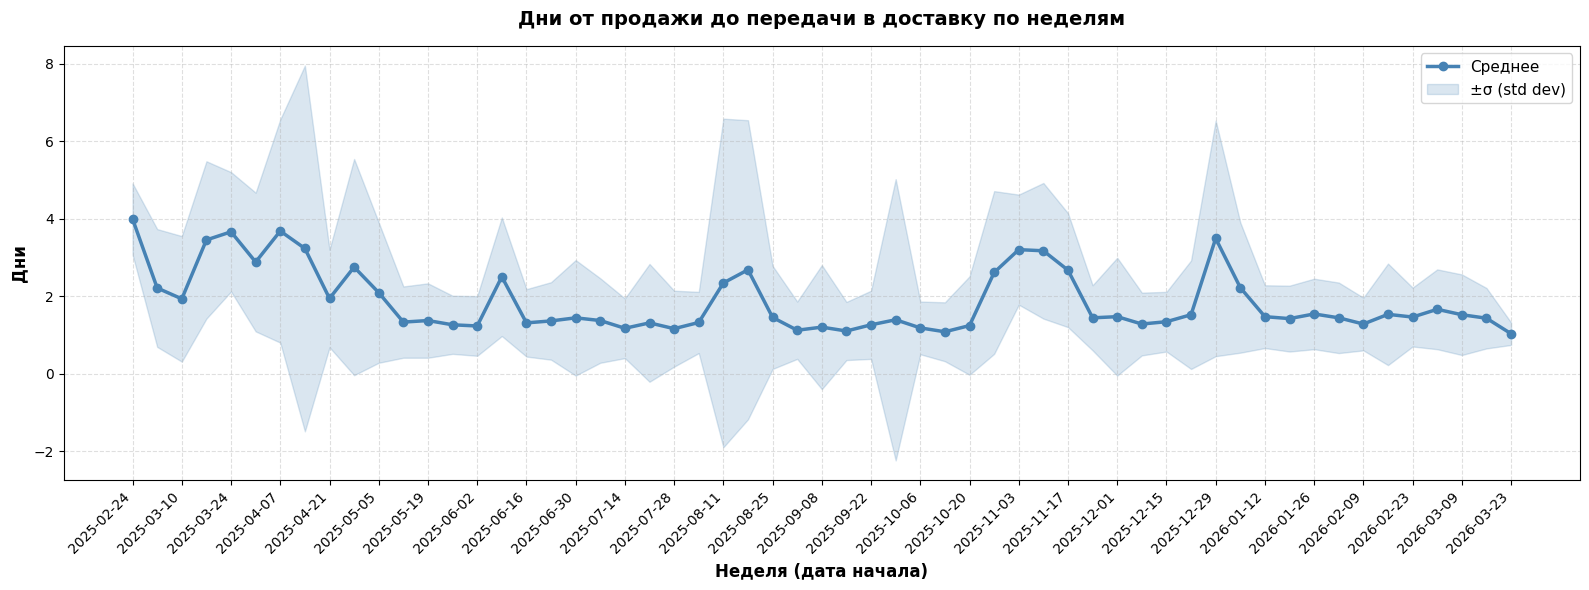

In [39]:
# ========== ГРАФИК 1: ВЫКУПЫ ПО ИСТОЧНИКАМ ЛИДОВ ==========
fig1 = plt.figure(figsize=(16, 6))

ax1 = fig1.add_subplot(1, 1, 1)
x_pos = np.arange(len(stats_source_filtered))

ax1.bar(x_pos, stats_source_filtered["buyout_count"], label="Количество выкупов", 
        color="steelblue", alpha=0.8, width=0.6)
ax1.set_xlabel("Источник лида", fontsize=12, fontweight="bold")
ax1.set_ylabel("Количество выкупов", fontsize=12, fontweight="bold", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(stats_source_filtered["lead_source_category"], rotation=45, ha="right", fontsize=10)

ax1_twin = ax1.twinx()
ax1_twin.plot(x_pos, stats_source_filtered["buyout_rate_pct"], 
         color="red", marker="o", linewidth=2.5, markersize=7, label="% выкупов")
ax1_twin.set_ylabel("Процент выкупов (%)", fontsize=12, fontweight="bold", color="red")
ax1_twin.tick_params(axis="y", labelcolor="red")

for i, v in enumerate(stats_source_filtered["buyout_count"]):
    ax1.text(i, v, str(int(v)), ha="center", va="bottom", fontweight="bold", fontsize=9)

for i, v in enumerate(stats_source_filtered["buyout_rate_pct"]):
    ax1_twin.text(i, v + 0.8, f"{v:.1f}%", ha="center", va="bottom", fontsize=9, color="red")

ax1.set_title("Выкупы по источникам лидов (≥10)", fontsize=13, fontweight="bold", pad=15)
ax1.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Сохраняем графика 1
fig1.savefig('../Cohort/outputs/charts/01_buyout_by_source.png', dpi=300, bbox_inches='tight')
plt.close(fig1)

# ========== ГРАФИК 2: Когортный анализ по месяцам (ОТДЕЛЬНО) ==========
fig2 = plt.figure(figsize=(16, 8))
ax2 = fig2.add_subplot(1, 1, 1)

im = ax2.imshow(pivot_sorted.fillna(0), aspect="auto", cmap="RdYlGn")

ax2.set_xticks(range(len(pivot_sorted.columns)))
ax2.set_xticklabels(pivot_sorted.columns, rotation=45, ha="right", fontsize=11)
ax2.set_yticks(range(len(pivot_sorted.index)))
ax2.set_yticklabels(pivot_sorted.index, fontsize=11)

for i in range(pivot_sorted.shape[0]):
    for j in range(pivot_sorted.shape[1]):
        value = pivot_sorted.iloc[i, j]
        if pd.notna(value):
            ax2.text(j, i, f"{value:.0f}%", ha="center", va="center", 
                    color="black", fontsize=9, fontweight="bold")

cbar = plt.colorbar(im, ax=ax2, label="% выкупа", shrink=0.8)
ax2.set_title("Когортный анализ: Выкупы по месяцам и источникам", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlabel("Месяц продажи", fontsize=12, fontweight="bold")
ax2.set_ylabel("Источник лида", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# Сохраняем график 2
fig2.savefig('../Cohort/outputs/charts/02_cohort_heatmap.png', dpi=300, bbox_inches='tight')
plt.close(fig2)

# ========== ГРАФИК 3: Временные показатели доставки (ОТДЕЛЬНО) ==========
fig3 = plt.figure(figsize=(16, 6))
ax3 = fig3.add_subplot(1, 1, 1)

x_pos = np.arange(len(cohort_timing))
week_dates = cohort_timing["week_start"].dt.strftime("%Y-%m-%d").values

ax3.plot(x_pos, cohort_timing["sale_to_delivery_mean"], marker="o", linewidth=2.5, 
        markersize=6, color="steelblue", label="Среднее")
ax3.fill_between(x_pos, 
                 cohort_timing["sale_to_delivery_mean"] - cohort_timing["sale_to_delivery_std"],
                 cohort_timing["sale_to_delivery_mean"] + cohort_timing["sale_to_delivery_std"],
                 alpha=0.2, color="steelblue", label="±σ (std dev)")

ax3.set_ylabel("Дни", fontsize=12, fontweight="bold")
ax3.set_xlabel("Неделя (дата начала)", fontsize=12, fontweight="bold")
ax3.set_title("Дни от продажи до передачи в доставку по неделям", fontsize=14, fontweight="bold", pad=15)
ax3.grid(True, alpha=0.4, linestyle="--")
ax3.legend(loc="upper right", fontsize=11)

# Больше подписей - каждые 2 недели если много, каждую неделю если мало
if len(x_pos) > 30:
    tick_step = 2
elif len(x_pos) > 15:
    tick_step = 1
else:
    tick_step = 1

ax3.set_xticks(x_pos[::tick_step])
labels_to_show = week_dates[::tick_step]
ax3.set_xticklabels(labels_to_show, rotation=45, ha="right", fontsize=10)

plt.tight_layout()
plt.show()

# Сохраняем график 3
fig3.savefig('../Cohort/outputs/charts/03_delivery_timing.png', dpi=300, bbox_inches='tight')
plt.close(fig3)

In [40]:
# ========== ОБЪЕДИНЕНИЕ ВСЕХ ГРАФИКОВ В ОДИН PDF ==========
from PIL import Image
import os
from pathlib import Path

charts_dir = Path('../Cohort/outputs/charts')
output_pdf = Path('../Cohort/outputs/all_charts_combined.pdf')

# Явный порядок графиков
image_order = [
    'cohort_sizes_weekly.png',
    'cohort_curves_weekly_selected.png',
    'cohort_heatmap_weekly_d30.png',
    '01_buyout_by_source.png',
    '02_cohort_heatmap.png',
    '03_delivery_timing.png',
    'final_buyout_rate_weekly.png',
    'final_buyout_rate_monthly.png'
]

# Открываем изображения в указанном порядке
images = []
for img_file in image_order:
    img_path = charts_dir / img_file
    if img_path.exists():
        # Открываем как RGB (для совместимости с PDF)
        img = Image.open(img_path).convert('RGB')
        # Приводим к стандартной ширине (макет A4)
        wpercent = (1240 / float(img.size[0]))
        hsize = int((float(img.size[1]) * float(wpercent)))
        img = img.resize((1240, hsize), Image.Resampling.LANCZOS)
        images.append(img)

# Сохраняем все изображения в один PDF
if images:
    images[0].save(output_pdf, save_all=True, append_images=images[1:])

In [41]:

# ========== СОХРАНЕНИЕ ДАННЫХ В EXCEL ==========
from openpyxl import load_workbook
from openpyxl.utils.dataframe import dataframe_to_rows

excel_path = Path('../Cohort/outputs/cohort_analysis_data.xlsx')

# Загружаем существующую книгу
try:
    wb = load_workbook(excel_path)
    # Удаляем листы если они уже есть (для переписи)
    if 'Выкупы по источникам' in wb.sheetnames:
        del wb['Выкупы по источникам']
    if 'Когортный анализ' in wb.sheetnames:
        del wb['Когортный анализ']
    if 'Временные метрики' in wb.sheetnames:
        del wb['Временные метрики']
except FileNotFoundError:
    # Если файла еще нет, создаем новый
    from openpyxl import Workbook
    wb = Workbook()
    if 'Sheet' in wb.sheetnames:
        del wb['Sheet']

# Лист 1: Выкупы по источникам
ws1 = wb.create_sheet('Выкупы по источникам', -1)
for r_idx, row in enumerate(dataframe_to_rows(stats_source_filtered, index=False, header=True), 1):
    for c_idx, value in enumerate(row, 1):
        ws1.cell(row=r_idx, column=c_idx, value=value)

# Лист 2: Когортный анализ
ws2 = wb.create_sheet('Когортный анализ', -1)
for r_idx, row in enumerate(dataframe_to_rows(pivot_sorted, index=True, header=True), 1):
    for c_idx, value in enumerate(row, 1):
        ws2.cell(row=r_idx, column=c_idx, value=value)

# Лист 3: Временные метрики
ws3 = wb.create_sheet('Временные метрики', -1)
for r_idx, row in enumerate(dataframe_to_rows(cohort_timing, index=False, header=True), 1):
    for c_idx, value in enumerate(row, 1):
        ws3.cell(row=r_idx, column=c_idx, value=value)

# Сохраняем книгу
wb.save(excel_path)
